# C++23 FX Option Pricer — Jupyter Demo

This notebook demonstrates the **pybind11 Python wrapper** around the C++ pricing engines.
All computation runs at native C++ speed; Python handles visualization and analysis.

**Instructions:**
1. Run Cell 1 (installs GCC 14 and builds the module, ~2 min)
2. Run Cell 2 (restart + import)
3. Run remaining cells

In [3]:
# ══════════════════════════════════════════════════════════════
# CELL 1: Install and build (run once)
# ══════════════════════════════════════════════════════════════
!sudo add-apt-repository -y ppa:ubuntu-toolchain-r/test 2>/dev/null
!sudo apt update -qq 2>/dev/null
!sudo apt install -y gcc-14 g++-14 libstdc++-14-dev 2>/dev/null
!pip install -q pybind11

!git clone https://github.com/quynhnguyen141299-hub/cpp20-option-pricer.git /content/cpp20-option-pricer 2>/dev/null; cd /content/cpp20-option-pricer && git pull

import subprocess
pybind11_dir = subprocess.run('python3 -c "import pybind11; print(pybind11.get_cmake_dir())"',
                              shell=True, capture_output=True, text=True).stdout.strip()

!cd /content/cpp20-option-pricer && rm -rf build && \
  cmake -DCMAKE_CXX_COMPILER=g++-14 -DBUILD_PYTHON=ON \
  -Dpybind11_DIR={pybind11_dir} -B build 2>&1 | tail -5 && \
  cmake --build build 2>&1 | tail -3

# Find and record GCC 14's libstdc++ directory for Cell 2
import subprocess, pathlib
result = subprocess.run('find /usr -name "libstdc++.so.6.0.*" 2>/dev/null | sort',
                        shell=True, capture_output=True, text=True)
all_libs = result.stdout.strip().split('\n')
# Pick the newest version (highest .so.6.0.XX number)
newest = sorted(all_libs, key=lambda p: int(p.rsplit('.',1)[-1]) if p.rsplit('.',1)[-1].isdigit() else 0)[-1]
gcc14_dir = str(pathlib.Path(newest).parent)
print(f'GCC 14 libstdc++ dir: {gcc14_dir}')

# Save the path so Cell 2 can use it
with open('/content/.gcc14_libdir', 'w') as f:
    f.write(gcc14_dir)

print()
print('=' * 50)
print('  DONE — now run Cell 2')
print('=' * 50)

PPA publishes dbgsym, you may need to include 'main/debug' component
Repository: 'deb https://ppa.launchpadcontent.net/ubuntu-toolchain-r/test/ubuntu/ jammy main'
Description:
Toolchain test builds; see https://wiki.ubuntu.com/ToolChain

More info: https://launchpad.net/~ubuntu-toolchain-r/+archive/ubuntu/test
Adding repository.
Found existing deb entry in /etc/apt/sources.list.d/ubuntu-toolchain-r-ubuntu-test-jammy.list
Adding deb entry to /etc/apt/sources.list.d/ubuntu-toolchain-r-ubuntu-test-jammy.list
Found existing deb-src entry in /etc/apt/sources.list.d/ubuntu-toolchain-r-ubuntu-test-jammy.list
Adding disabled deb-src entry to /etc/apt/sources.list.d/ubuntu-toolchain-r-ubuntu-test-jammy.list
Adding key to /etc/apt/trusted.gpg.d/ubuntu-toolchain-r-ubuntu-test.gpg with fingerprint C8EC952E2A0E1FBDC5090F6A2C277A0A352154E5
Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy

In [1]:
# ══════════════════════════════════════════════════════════════
# CELL 2: Import (run after Cell 1)
# ══════════════════════════════════════════════════════════════
import os, sys, ctypes

# Load GCC 14's libstdc++ before importing the C++ module
with open('/content/.gcc14_libdir') as f:
    gcc14_dir = f.read().strip()
os.environ['LD_LIBRARY_PATH'] = gcc14_dir + ':' + os.environ.get('LD_LIBRARY_PATH', '')
# Force the linker to use GCC 14's version right now
ctypes.CDLL(os.path.join(gcc14_dir, 'libstdc++.so.6'), mode=ctypes.RTLD_GLOBAL)

sys.path.insert(0, '/content/cpp20-option-pricer/build')

import fx_pricer as fp
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

print('Ready:', [x for x in dir(fp) if not x.startswith('_')])

Ready: ['BSEngine', 'BarrierContract', 'BarrierMCEngine', 'BarrierType', 'Contract', 'Exercise', 'FDConfig', 'FDEngine', 'Greeks', 'HestonMCEngine', 'HestonParams', 'MCConfig', 'MCEngine', 'MarketSnap', 'OptType', 'PricingResult', 'Rate', 'Spot', 'Strike', 'Vol', 'YearFrac']


---
## 1. BS vs MC Cross-Validation

Price a EURUSD call with both engines and verify they agree within Monte Carlo standard error.

In [2]:
mkt = fp.MarketSnap(S=1.085, sigma=0.075, r_d=0.0435, r_f=0.025)
call = fp.Contract(K=1.09, T=0.25, type=fp.OptType.Call)

bs = fp.BSEngine()
bs_r = bs.price(call, mkt)
print(f"BS price:  {bs_r.price:.8f}")
print(f"Greeks:    Δ={bs_r.greeks.delta:+.6f}  Γ={bs_r.greeks.gamma:.6f}  "
      f"V={bs_r.greeks.vega:.6f}  Θ={bs_r.greeks.theta:.6f}")

cfg = fp.MCConfig()
cfg.n_paths = 500_000
cfg.antithetic = True
cfg.control_variate = True
cfg.n_threads = 1
mc = fp.MCEngine(r_d=0.0435, sigma=0.075, config=cfg)
mc_r = mc.price(call, mkt)
print(f"\nMC price:  {mc_r.price:.8f} ± {mc_r.std_err:.2e}")
print(f"Diff:      {abs(bs_r.price - mc_r.price):.2e} (< 1 SE = {mc_r.std_err:.2e})")

BS price:  0.01614438
Greeks:    Δ=+0.504606  Γ=9.742094  V=0.002150  Θ=-0.000114

MC price:  0.01614307 ± 3.26e-05
Diff:      1.31e-06 (< 1 SE = 3.26e-05)


Prices the same EURUSD call (K=1.09, T=3 months) using two independent engines — Black-Scholes (analytical formula) and Monte Carlo (500K random paths). The point: if both produce the same price within Monte Carlo standard error, you've verified your MC engine is correctly implemented. This is a standard quant validation step.



---
## 2. Greeks Surface — Delta & Gamma vs Spot

Sweep spot from 1.05 to 1.13 and plot how delta and gamma evolve.

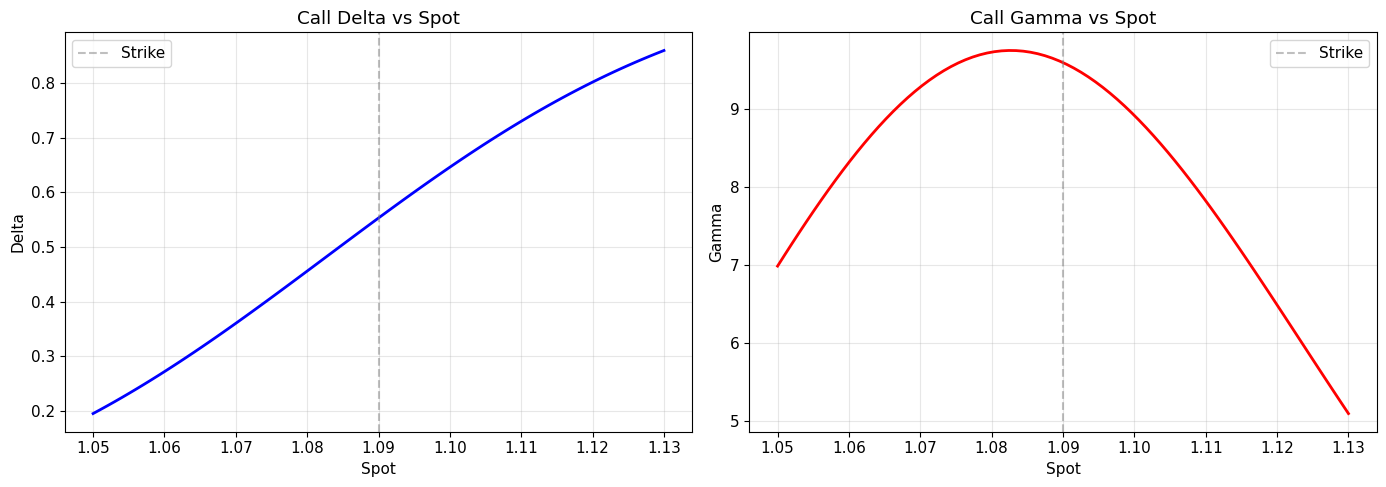

In [3]:
spots = np.linspace(1.05, 1.13, 80)
deltas, gammas = [], []

for s in spots:
    m = fp.MarketSnap(S=s, sigma=0.075, r_d=0.0435, r_f=0.025)
    r = bs.price(call, m)
    deltas.append(r.greeks.delta)
    gammas.append(r.greeks.gamma)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(spots, deltas, 'b-', linewidth=2)
ax1.axvline(1.09, color='grey', linestyle='--', alpha=0.5, label='Strike')
ax1.set_xlabel('Spot')
ax1.set_ylabel('Delta')
ax1.set_title('Call Delta vs Spot')
ax1.legend()

ax2.plot(spots, gammas, 'r-', linewidth=2)
ax2.axvline(1.09, color='grey', linestyle='--', alpha=0.5, label='Strike')
ax2.set_xlabel('Spot')
ax2.set_ylabel('Gamma')
ax2.set_title('Call Gamma vs Spot')
ax2.legend()

plt.tight_layout()
plt.show()

Sweeps the spot rate from 1.05 to 1.13 and plots how delta (price sensitivity) and gamma (delta's rate of change) evolve. Delta follows an S-curve; gamma peaks near the strike where the option is most sensitive. This shows a trader where hedging risk is concentrated.

Delta rises in an S-curve shape, which is characteristic of a call option.

---
## 3. Heston Volatility Smile

The Heston model generates a realistic implied vol smile. Negative ρ → downside skew.

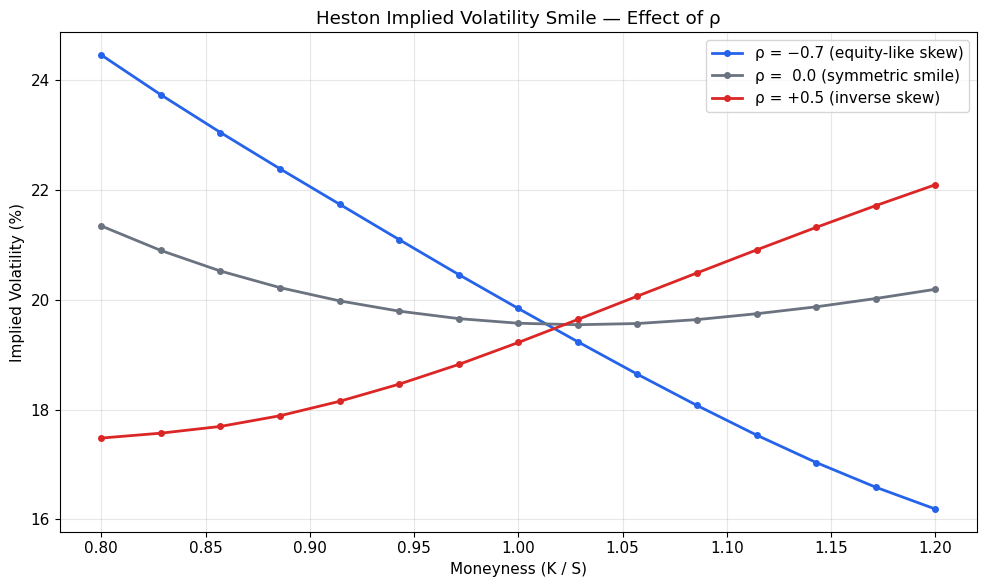

In [4]:
params = fp.HestonParams()
params.v0 = 0.04
params.kappa = 1.5
params.theta = 0.04
params.xi = 0.3

S, r_d, r_f, T = 100.0, 0.05, 0.0, 0.5
moneyness = np.linspace(0.80, 1.20, 15)
strikes = S * moneyness

fig, ax = plt.subplots(figsize=(10, 6))

for rho, color, label in [(-0.7, '#2563eb', 'ρ = −0.7 (equity-like skew)'),
                           (0.0,  '#6b7280', 'ρ =  0.0 (symmetric smile)'),
                           (0.5,  '#dc2626', 'ρ = +0.5 (inverse skew)')]:
    params.rho = rho
    cfg = fp.MCConfig()
    cfg.n_paths = 200_000
    cfg.steps = 50
    cfg.antithetic = True
    cfg.n_threads = 1
    hmc = fp.HestonMCEngine(r_d=r_d, params=params, config=cfg)
    mkt_h = fp.MarketSnap(S=S, sigma=0.20, r_d=r_d, r_f=r_f)

    ivs = []
    for K in strikes:
        c = fp.Contract(K=K, T=T, type=fp.OptType.Call)
        r = hmc.price(c, mkt_h)
        try:
            iv = bs.implied_vol(c, mkt_h, r.price)
            ivs.append(iv * 100)
        except:
            ivs.append(np.nan)

    ax.plot(moneyness, ivs, 'o-', color=color, linewidth=2, markersize=4, label=label)

ax.set_xlabel('Moneyness (K / S)')
ax.set_ylabel('Implied Volatility (%)')
ax.set_title('Heston Implied Volatility Smile — Effect of ρ')
ax.legend()
plt.tight_layout()
plt.show()

Runs the Heston stochastic volatility model with three different correlation values (rho = -0.7, 0.0, +0.5) and plots the implied volatility across strikes. Negative rho produces downside skew (OTM puts are more expensive) — the pattern seen in real equity/FX markets. This demonstrates that your Heston engine reproduces realistic vol surfaces that Black-Scholes alone cannot.



---
## 4. Barrier Option — Knockout Probability

Down-and-Out call: as the barrier approaches spot, the option loses value rapidly.

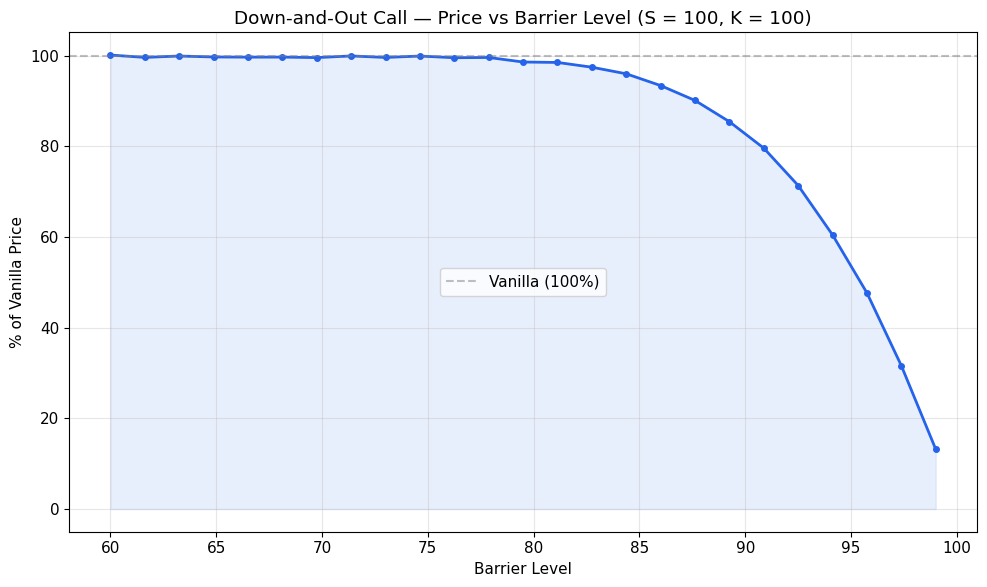

In [5]:
mkt_b = fp.MarketSnap(S=100.0, sigma=0.20, r_d=0.05, r_f=0.0)

vanilla = bs.price(fp.Contract(K=100.0, T=1.0, type=fp.OptType.Call), mkt_b)

cfg_b = fp.MCConfig()
cfg_b.n_paths = 200_000
cfg_b.steps = 100
cfg_b.antithetic = True
cfg_b.n_threads = 1
bmc = fp.BarrierMCEngine(r_d=0.05, sigma=0.20, config=cfg_b)

barriers = np.linspace(60, 99, 25)
pct_vanilla = []

for B in barriers:
    bc = fp.BarrierContract(
        K=100.0, T=1.0, type=fp.OptType.Call,
        barrier=B, barrier_type=fp.BarrierType.DownAndOut
    )
    r = bmc.price_barrier(bc, mkt_b)
    pct_vanilla.append(100 * r.price / vanilla.price)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(barriers, pct_vanilla, 'o-', color='#2563eb', linewidth=2, markersize=4)
ax.axhline(100, color='grey', linestyle='--', alpha=0.5, label='Vanilla (100%)')
ax.fill_between(barriers, pct_vanilla, alpha=0.1, color='#2563eb')
ax.set_xlabel('Barrier Level')
ax.set_ylabel('% of Vanilla Price')
ax.set_title('Down-and-Out Call — Price vs Barrier Level (S = 100, K = 100)')
ax.legend()
plt.tight_layout()
plt.show()

Prices a Down-and-Out call across different barrier levels (60 to 99) and shows the price as a percentage of the equivalent vanilla call. As the barrier approaches spot (100), the chance of being knocked out rises sharply and the option becomes nearly worthless. This visualizes the nonlinear risk profile of exotic barrier options.



---
## 5. FD PDE Solver — American vs European Early Exercise

Sweep spot to show where the American put's early exercise premium is maximum.

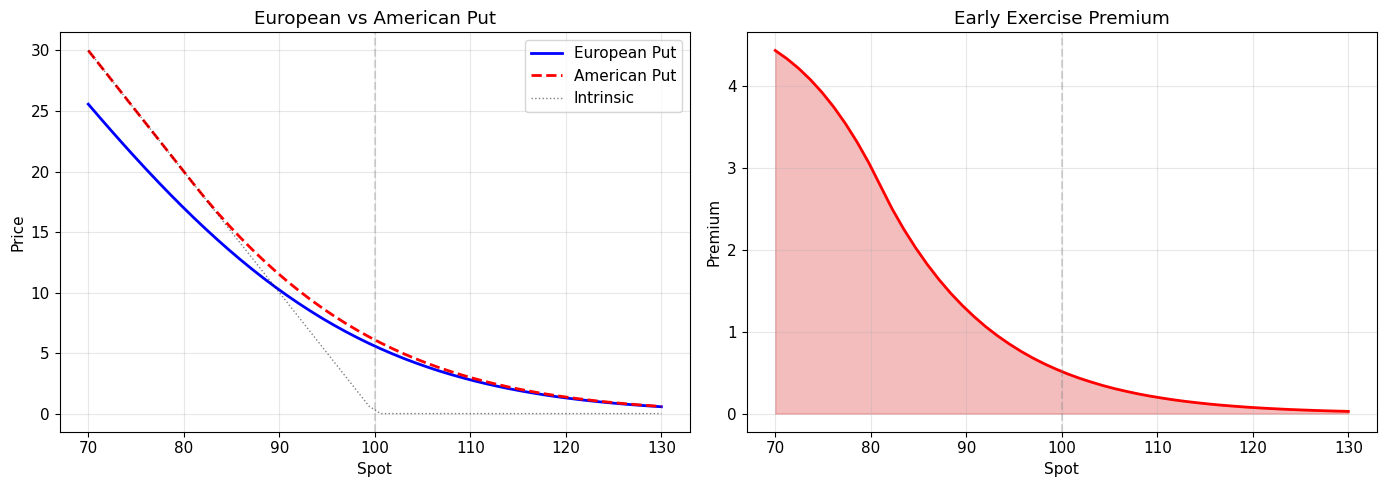

In [6]:
fd = fp.FDEngine()
spots_fd = np.linspace(70, 130, 50)

eu_prices, am_prices, premiums = [], [], []

for s in spots_fd:
    m = fp.MarketSnap(S=s, sigma=0.20, r_d=0.05, r_f=0.0)
    eu_put = fp.Contract(K=100.0, T=1.0, type=fp.OptType.Put)
    am_put = fp.Contract(K=100.0, T=1.0, type=fp.OptType.Put, exercise=fp.Exercise.American)

    eu_r = fd.price(eu_put, m)
    am_r = fd.price(am_put, m)
    eu_prices.append(eu_r.price)
    am_prices.append(am_r.price)
    premiums.append(am_r.price - eu_r.price)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(spots_fd, eu_prices, 'b-', linewidth=2, label='European Put')
ax1.plot(spots_fd, am_prices, 'r--', linewidth=2, label='American Put')
ax1.plot(spots_fd, np.maximum(100 - spots_fd, 0), 'k:', linewidth=1, alpha=0.5, label='Intrinsic')
ax1.axvline(100, color='grey', linestyle='--', alpha=0.3)
ax1.set_xlabel('Spot')
ax1.set_ylabel('Price')
ax1.set_title('European vs American Put')
ax1.legend()

ax2.fill_between(spots_fd, premiums, alpha=0.3, color='#dc2626')
ax2.plot(spots_fd, premiums, 'r-', linewidth=2)
ax2.axvline(100, color='grey', linestyle='--', alpha=0.3)
ax2.set_xlabel('Spot')
ax2.set_ylabel('Premium')
ax2.set_title('Early Exercise Premium')

plt.tight_layout()
plt.show()

Uses the finite-difference engine to price both European and American puts across a range of spots, then plots the early exercise premium (the difference). The premium is max for deep in-the-money puts, where exercising early to collect cash now (and earn interest) beats waiting.

This validates that the PDE solver correctly handles the American free-boundary problem.



---
## 6. MC Convergence — Paths vs Price Error

Show how MC price converges to the BS analytical answer as we increase the number of paths.

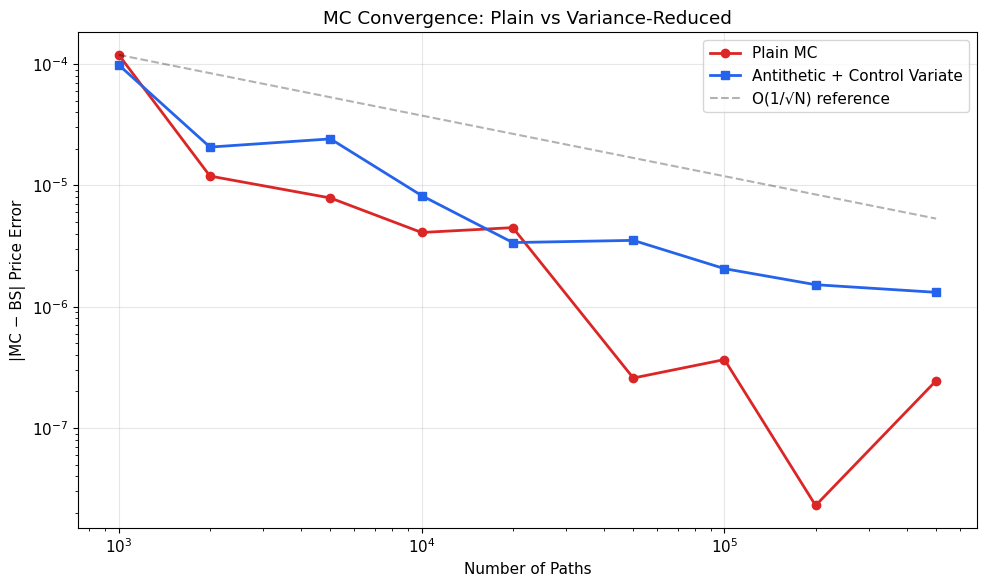

In [7]:
mkt_cv = fp.MarketSnap(S=1.085, sigma=0.075, r_d=0.0435, r_f=0.025)
call_cv = fp.Contract(K=1.09, T=0.25, type=fp.OptType.Call)
bs_ref = bs.price(call_cv, mkt_cv).price

path_counts = [1000, 2000, 5000, 10_000, 20_000, 50_000, 100_000, 200_000, 500_000]
errors_plain, errors_cv = [], []

for n in path_counts:
    cfg_p = fp.MCConfig()
    cfg_p.n_paths = n
    cfg_p.antithetic = False
    cfg_p.control_variate = False
    cfg_p.n_threads = 1
    mc_p = fp.MCEngine(r_d=0.0435, sigma=0.075, config=cfg_p)
    r_p = mc_p.price(call_cv, mkt_cv)
    errors_plain.append(abs(r_p.price - bs_ref))

    cfg_cv = fp.MCConfig()
    cfg_cv.n_paths = n
    cfg_cv.antithetic = True
    cfg_cv.control_variate = True
    cfg_cv.n_threads = 1
    mc_cv = fp.MCEngine(r_d=0.0435, sigma=0.075, config=cfg_cv)
    r_cv = mc_cv.price(call_cv, mkt_cv)
    errors_cv.append(abs(r_cv.price - bs_ref))

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(path_counts, errors_plain, 'o-', color='#dc2626', linewidth=2, label='Plain MC')
ax.loglog(path_counts, errors_cv, 's-', color='#2563eb', linewidth=2, label='Antithetic + Control Variate')

ref = errors_plain[0] * np.sqrt(path_counts[0]) / np.sqrt(path_counts)
ax.loglog(path_counts, ref, 'k--', alpha=0.3, label='O(1/√N) reference')

ax.set_xlabel('Number of Paths')
ax.set_ylabel('|MC − BS| Price Error')
ax.set_title('MC Convergence: Plain vs Variance-Reduced')
ax.legend()
plt.tight_layout()
plt.show()

Runs Monte Carlo at increasing path counts (1K to 500K) in two modes: plain MC and variance-reduced MC (antithetic + control variate). Plots the error vs BS on a log-log scale. Plain MC follows the theoretical O(1/sqrt(N)) convergence line. The variance-reduced version converges much faster — reaching the same accuracy with far fewer paths, which means less compute cost.



---
## 7. Implied Vol Solver Round-Trip

Price → IV → re-price: the Newton-Raphson solver recovers the original vol to machine precision.

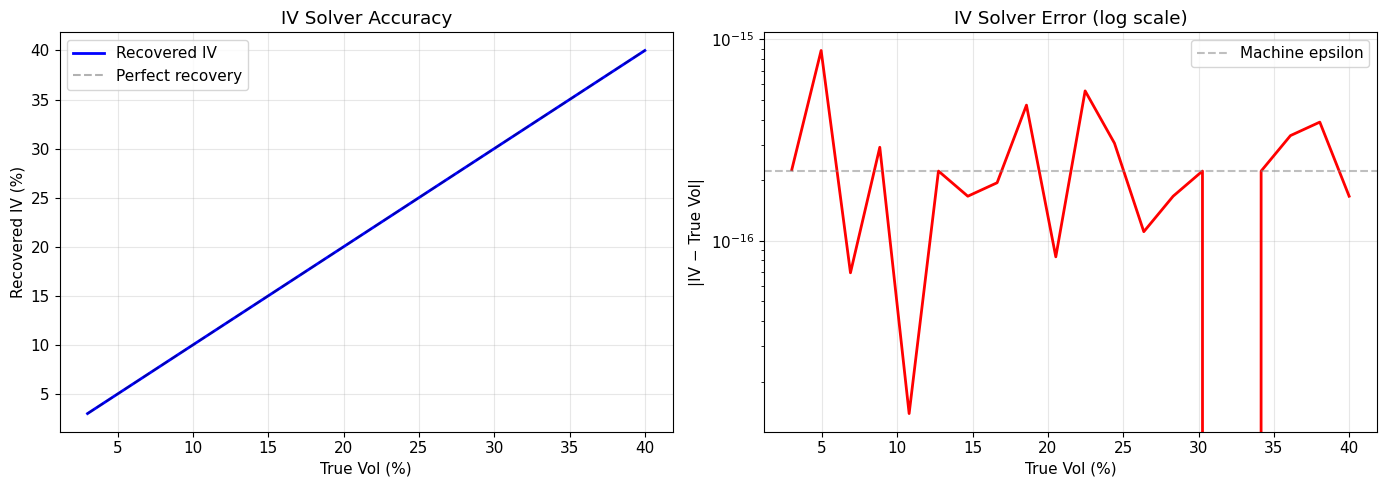

In [8]:
vols = np.linspace(0.03, 0.40, 20)
recovered, errors_iv = [], []

for v in vols:
    m = fp.MarketSnap(S=1.085, sigma=v, r_d=0.0435, r_f=0.025)
    c = fp.Contract(K=1.09, T=0.25, type=fp.OptType.Call)
    px = bs.price(c, m).price

    guess = fp.MarketSnap(S=1.085, sigma=0.30, r_d=0.0435, r_f=0.025)
    iv = bs.implied_vol(c, guess, px)
    recovered.append(iv * 100)
    errors_iv.append(abs(iv - v))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(vols * 100, recovered, 'b-', linewidth=2, label='Recovered IV')
ax1.plot(vols * 100, vols * 100, 'k--', alpha=0.3, label='Perfect recovery')
ax1.set_xlabel('True Vol (%)')
ax1.set_ylabel('Recovered IV (%)')
ax1.set_title('IV Solver Accuracy')
ax1.legend()

ax2.semilogy(vols * 100, errors_iv, 'r-', linewidth=2)
ax2.axhline(2.22e-16, color='grey', linestyle='--', alpha=0.5, label='Machine epsilon')
ax2.set_xlabel('True Vol (%)')
ax2.set_ylabel('|IV − True Vol|')
ax2.set_title('IV Solver Error (log scale)')
ax2.legend()

plt.tight_layout()
plt.show()

Takes 20 different true volatilities, prices each with BS, then recovers the vol using the Newton-Raphson IV solver. The left plot shows perfect recovery (recovered IV = true vol). The right plot shows the absolute error on a log scale — it's near machine epsilon (~2.2e-16), proving the solver is numerically precise to the limits of double-precision floating point.



---

**Summary:** All pricing engines are accessible from Python via pybind11. The C++ library handles the computation; Python handles the visualization and analysis workflow.

Taken together, the notebook demonstrates every engine in the C++ library (BS, MC, Heston MC, Barrier MC, FD PDE, IV solver) with visual proof that each one works correctly — validation script trusting a pricing library in production.



You just import fx_pricer in Python and call functions like any normal Python library — but under the hood, all the heavy numerical work (Monte Carlo simulations, PDE solvers, matrix math) runs as compiled C++ code. That's typically 50-100x faster than the same algorithms written in pure Python or NumPy.



What you can do in Python using the finished C++ options pricer:

1. Price an option in one line — pass in spot, strike, vol, rates, and get back a price + Greeks

2. Run Monte Carlo simulations — 500K paths complete in milliseconds, not minutes in (Demo 1) That's 500,000 simulated price paths with antithetic sampling and control variates, executed through your C++ engine via the pybind11 wrapper. On Colab, that cell completes in under a second; and in (Demo 6 MC Convergence) you run Monte Carlo 18 times — at path counts from 1,000 up to 500,000 in both plain and variance-reduced modes — all within a single cell execution. If that same 500K-path simulation were written in pure Python with for loops, it would take minutes. The C++ engine handles it in milliseconds because the path generation, payoff computation, and averaging all happen in compiled native code — Python just triggers it and receives the result.


3. Generate vol surfaces — sweep strikes and expiries through the Heston model to build realistic IV (Demo 3) does this. Heston Volatility Smile sweeps 15 strikes across moneyness from 0.80 to 1.20 and runs each through the Heston Monte Carlo engine at 200K paths, then back-solves for IV using the Newton-Raphson IV solver. It does this three times for different rho values, producing the vol smile curves - 1D smile (vol vs strike at a single expiry). A full vol surface would add a second dimension — repeating that sweep across multiple expiries (e.g., 1W, 1M, 3M, 6M, 1Y). That would give you a 3D surface: strike x expiry x implied vol (future implementation path, 1D for visualisation for now).

3. Backtest hedging strategies — use the Greeks output to simulate delta-hedging P&L (e.g., below)



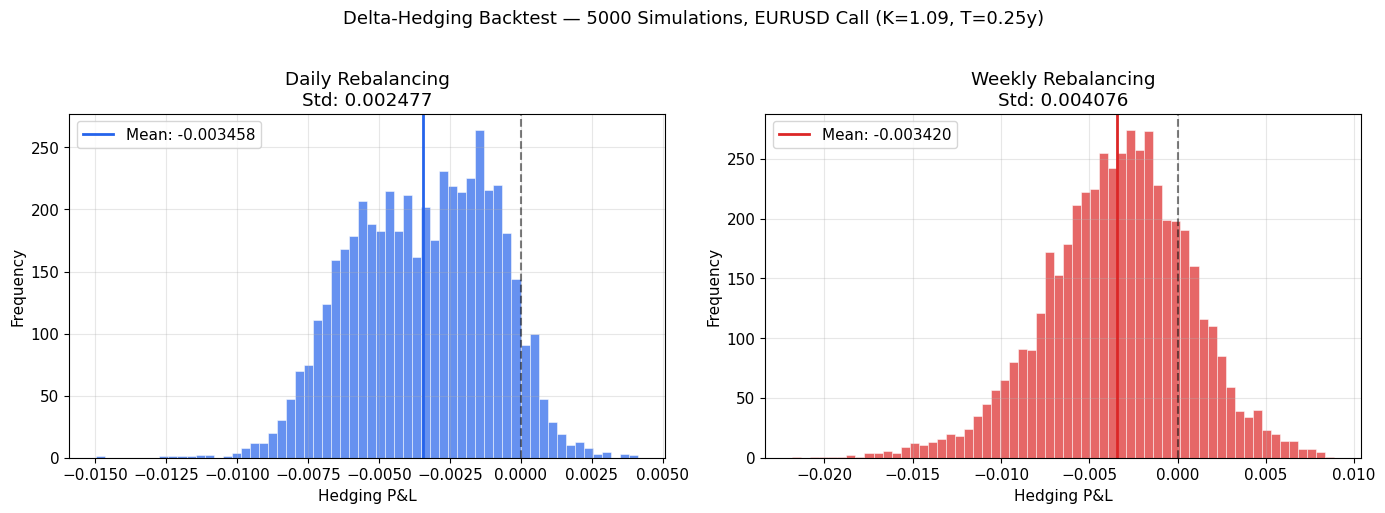

                            Daily       Weekly
            Mean P&L    -0.003458    -0.003420
             Std P&L     0.002477     0.004076
           95% range [-0.008412, 0.001495] [-0.011572, 0.004733]


In [9]:
# ══════════════════════════════════════════════════════════════
# Delta-Hedging Backtest: Daily vs Weekly Rebalancing
# ══════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Option and market parameters
S0, K, T, sigma = 1.085, 1.09, 0.25, 0.075
r_d, r_f = 0.0435, 0.025
n_days = int(T * 252)          # ~63 trading days
dt = T / n_days
n_sims = 5000                  # number of backtest runs

bs = fp.BSEngine()

def run_hedging_backtest(rebalance_every=1):
    """Simulate delta-hedging P&L over n_sims paths."""
    pnls = []
    for _ in range(n_sims):
        spot = S0
        # Initial delta hedge
        mkt = fp.MarketSnap(S=spot, sigma=sigma, r_d=r_d, r_f=r_f)
        contract = fp.Contract(K=K, T=T, type=fp.OptType.Call)
        result = bs.price(contract, mkt)
        premium = result.price
        delta = result.greeks.delta

        cash = premium - delta * spot   # sold call, bought delta shares
        holding = delta

        for day in range(1, n_days + 1):
            # Spot moves via GBM
            z = np.random.randn()
            spot *= np.exp((r_d - r_f - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)

            # Cash earns domestic rate
            cash *= np.exp(r_d * dt)
            # Spot holding earns foreign rate (FX carry)
            holding_value_growth = np.exp(r_f * dt)

            remaining_T = T - day * dt

            if remaining_T > 1e-6 and day % rebalance_every == 0:
                mkt = fp.MarketSnap(S=spot, sigma=sigma, r_d=r_d, r_f=r_f)
                contract = fp.Contract(K=K, T=remaining_T, type=fp.OptType.Call)
                new_delta = bs.price(contract, mkt).greeks.delta

                # Rebalance: adjust spot holding to match new delta
                trade = new_delta - holding
                cash -= trade * spot    # buy/sell spot
                holding = new_delta

        # At expiry: settle option payoff
        payoff = max(spot - K, 0)
        final_pnl = cash + holding * spot - payoff
        pnls.append(final_pnl)

    return np.array(pnls)

# Run backtests
pnl_daily  = run_hedging_backtest(rebalance_every=1)   # daily
pnl_weekly = run_hedging_backtest(rebalance_every=5)   # weekly

# ── Plot results ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pnl, label, color in [
    (axes[0], pnl_daily,  'Daily Rebalancing',  '#2563eb'),
    (axes[1], pnl_weekly, 'Weekly Rebalancing', '#dc2626')]:

    ax.hist(pnl, bins=60, color=color, alpha=0.7, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.axvline(pnl.mean(), color=color, linestyle='-', linewidth=2,
               label=f'Mean: {pnl.mean():.6f}')
    ax.set_xlabel('Hedging P&L')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{label}\nStd: {pnl.std():.6f}')
    ax.legend()

plt.suptitle(f'Delta-Hedging Backtest — {n_sims} Simulations, EURUSD Call (K={K}, T={T}y)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary stats
print(f"{'':>20} {'Daily':>12} {'Weekly':>12}")
print(f"{'Mean P&L':>20} {pnl_daily.mean():>12.6f} {pnl_weekly.mean():>12.6f}")
print(f"{'Std P&L':>20} {pnl_daily.std():>12.6f} {pnl_weekly.std():>12.6f}")
print(f"{'95% range':>20} [{pnl_daily.mean()-2*pnl_daily.std():.6f}, {pnl_daily.mean()+2*pnl_daily.std():.6f}]"
      f" [{pnl_weekly.mean()-2*pnl_weekly.std():.6f}, {pnl_weekly.mean()+2*pnl_weekly.std():.6f}]")

- From Cell 1, a EURUSD call with spot at 1.085 and BS premium is 0.01614.
- So the daily hedge std of 0.0025 (round up from 0.002477); is around 15% of the option premium — meaning our hedge captures most of the risk, but not all. The 25% residual is the unavoidable cost of hedging in discrete time.




**These are the two histograms from our delta-hedging backtest — each one shows distribution of hedging P&L across 5,000 simulated paths.**

- **Left (Blue): Daily Rebalancing**
1. The P&L is clustered tightly around the mean (-0.0035)
2. The range is narrow: roughly -0.015 to +0.005
3. Std = 0.0025 — the hedge is working well, capturing most of the option's risk
4. The shape is slightly left-skewed (longer tail on the negative side) — that's gamma: large spot moves hurt more than small moves help

- **Right (Red): Weekly Rebalancing**
1. Same mean (-0.0034), but the distribution is noticeably wider
2. The range stretches from -0.020 to +0.010;
3. Std = 0.0041 — about 65% more variance than daily
4. The left tail is fatter — more scenarios with larger losses

**What the charts tell:**
- Both distributions are centered slightly below zero (the dashed line), not exactly at zero. That small negative drag is the cost of being short gamma — between rebalances, you're always a little behind the market.

- The visual difference between the two is the core takeaway: less frequent hedging = wider P&L distribution = more risk. A trader looking at these charts would conclude that daily rebalancing keeps the hedge tight, while weekly leaves too much gamma exposure — especially on the downside where the fat left tail sits.

- This is exactly the kind of analysis a risk manager would run to justify hedging frequency to a portfolio manager.